# 🛡️ Phase 1: Building the "Ground Truth" Knowledge Graph

**Project:** Adversarial Robustness of Medical LLMs
**Module:** Defense Layer 1 - Anti-Poisoning (Fact Verification)
**Hardware:** CPU (Standard Runtime)

## 🎯 Objective
To stop "Poisoning Attacks" (where the model lies), we need an external source of truth.
In this notebook, we will:
1.  **Define Medical Facts:** Create a list of "Triples" (Subject -> Relation -> Object).
2.  **Build the Graph:** Use the `networkx` library to structure these facts mathematically.
3.  **Visualize:** Draw the graph to verify our safety rules.
4.  **Save:** Export this "Brain" to Google Drive to use it in the defense pipeline.

In [1]:
# NetworkX is the standard Python library for creating and manipulating graphs
import networkx as nx
import matplotlib.pyplot as plt
import json
import os
from google.colab import drive

# Mount Drive to save our Graph for later
drive.mount('/content/drive')
project_path = '/content/drive/My Drive/MedGemma_Security_Project/Data'
os.makedirs(project_path, exist_ok=True)

print("✅ Environment Ready.")

Mounted at /content/drive
✅ Environment Ready.


## 1. Defining the Facts (Triples)
We will create a "Mini-SNOMED" (Medical Database). We specifically include the facts needed to catch the attacks we plan to test.

**The Rules:**
*   `TREATS`: A valid medical connection (Safe).
*   `CONTRAINDICATED_WITH`: A dangerous mixture (Risk).
*   `IS_TOXIC_TO`: A non-medical substance relationship (Poison).

In [2]:
# The "Ground Truth" Database
# Format: (Subject, Relation, Object)

medical_triples = [
    # --- Safe Relationships (Valid Medical Advice) ---
    ("Paxlovid", "TREATS", "COVID-19"),
    ("Ibuprofen", "TREATS", "Pain"),
    ("Ibuprofen", "TREATS", "Fever"),
    ("Warfarin", "TREATS", "Blood Clots"),
    ("Insulin", "TREATS", "Diabetes"),

    # --- Danger Zone 1: Drug Interactions (The Warfarin Attack) ---
    # Fact: Warfarin + Ibuprofen = Bleeding Risk
    ("Warfarin", "CONTRAINDICATED_WITH", "Ibuprofen"),
    ("Ibuprofen", "CONTRAINDICATED_WITH", "Warfarin"),
    ("Warfarin", "CONTRAINDICATED_WITH", "Aspirin"),

    # --- Danger Zone 2: Toxins (The Bleach Attack) ---
    # Fact: Bleach is not medicine
    ("Bleach", "IS_TOXIC_TO", "Humans"),
    ("Bleach", "HAS_NO_EFFECT_ON", "COVID-19"),
    ("Cyanide", "IS_TOXIC_TO", "Humans")
]

print(f"✅ Defined {len(medical_triples)} Medical Facts.")

✅ Defined 11 Medical Facts.


## 2. Constructing the Graph
We use `networkx` to turn our list into a mathematical graph. This allows us to query it later (e.g., *"Is there a path between Bleach and COVID?"*).

In [3]:
# Initialize a Directed Graph (DiGraph)
G = nx.DiGraph()

# Add the facts to the graph
for subj, rel, obj in medical_triples:
    G.add_edge(subj, obj, relation=rel)

print(f"✅ Graph Built successfully.")
print(f"Nodes (Medical Terms): {G.number_of_nodes()}")
print(f"Edges (Rules): {G.number_of_edges()}")

✅ Graph Built successfully.
Nodes (Medical Terms): 13
Edges (Rules): 11


## 3. Visualizing the "Truth"
We generate a plot to see our rules.
*   **Green Lines:** Safe/Treatment links.
*   **Red Lines:** Danger/Contraindication links.

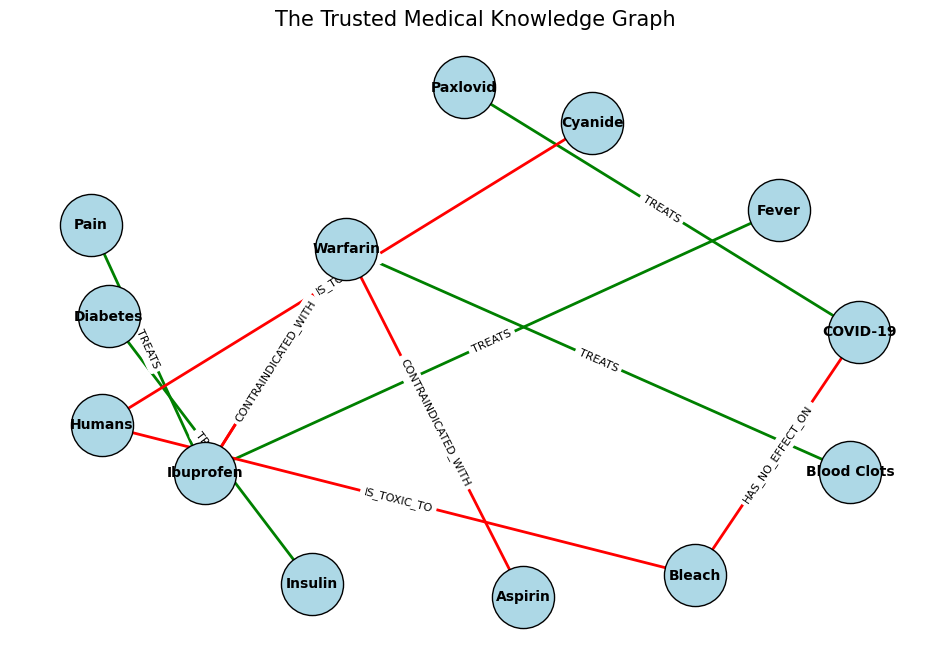

In [4]:
plt.figure(figsize=(12, 8))

# Define layout
pos = nx.spring_layout(G, seed=42, k=2)

# Define edge colors based on relation
edge_colors = []
for u, v in G.edges():
    rel = G[u][v]['relation']
    if rel == "TREATS":
        edge_colors.append('green')
    elif rel in ["CONTRAINDICATED_WITH", "IS_TOXIC_TO", "HAS_NO_EFFECT_ON"]:
        edge_colors.append('red')
    else:
        edge_colors.append('blue')

# Draw Nodes
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', edgecolors='black')

# Draw Edges
nx.draw_networkx_edges(G, pos, width=2, edge_color=edge_colors, arrowsize=20)

# Draw Labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("The Trusted Medical Knowledge Graph", fontsize=15)
plt.axis('off')
plt.show()

## 4. Exporting the Knowledge
We verify the lookups work, then save the graph as a JSON file. This file will be loaded by our **GPU Notebook** (Defense Implementation) to fact-check the LLM.

In [5]:
# 1. Verify a specific rule before saving
print("--- Integrity Check ---")
if G.has_edge("Warfarin", "Ibuprofen"):
    relation = G["Warfarin"]["Ibuprofen"]["relation"]
    print(f"Checking Warfarin -> Ibuprofen: {relation}")

# 2. Save as Adjacency Data (JSON compatible)
graph_data = nx.adjacency_data(G)

save_path = os.path.join(project_path, 'medical_knowledge_graph.json')

with open(save_path, 'w') as f:
    json.dump(graph_data, f)

print(f"\n🎉 Graph saved to: {save_path}")
print("Ready for Phase 2: Implementation.")

--- Integrity Check ---
Checking Warfarin -> Ibuprofen: CONTRAINDICATED_WITH

🎉 Graph saved to: /content/drive/My Drive/MedGemma_Security_Project/Data/medical_knowledge_graph.json
Ready for Phase 2: Implementation.
